# Distributed Training with Multiple GPUs (in beta)

This notebook quickly covers the controls associated with distributed training in Hyrax. The key points are listed below:

- Once an instance of Hyrax is created with `h = Hyrax()`, the configuration to control distributed training can be set to `True` or `False` through `h.config['general']['distributed']`. By default, it is set to `False`.

- When `h.config['general']['distributed']` is set to `True` will automatically attempt to use all available GPUs. If only some subset of the available GPUs are desired, then import the `os` library and use `os.environ['CUDA_VISIBLE_DEVICES']` to select which GPUs should be visible in the current environment for Hyrax to use.

- It is imperative that the `train_batch` and `validate_batch` methods on a Hyrax model call `self()` or `self.forward()`. If `self.forward()` is simply a wrapper for some other method, and that other method is called in `*_batch` rather than the forward method, then distributed training will not work properly.

Below is an example of distributed training using a HyraxCNN model with the CIFAR10 dataset, like in the [Getting Started](<getting_started.ipynb>) notebook. Note that there is one progress bar for each GPU used during training; the presence of more than one bar indicates that distributed training is successful. Distributed support is currently under development; if you experience any issues with distributed training, it can always be turned off and Hyrax will revert to single-GPU training.

In [ ]:
from hyrax import Hyrax
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import pickle


def show_confusion_matrix(test_data, predicted_classes):
    y_true = test_data[b"labels"]
    y_pred = predicted_classes.tolist()

    correct = 0
    for t, p in zip(y_true, y_pred):
        correct += t == p

    print("\nAccuracy for test dataset:", correct / len(y_true))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()


data_request_definition = {
    "train": {
        "data": {
            "dataset_class": "HyraxCifarDataset",
            "data_location": "./data",
            "fields": ["image", "label"],
            "primary_id_field": "object_id",
        },
    },
    "infer": {
        "data": {
            "dataset_class": "HyraxCifarDataset",
            "data_location": "./data",
            "fields": ["image", "object_id"],
            "primary_id_field": "object_id",
            "dataset_config": {
                "HyraxCifarDataset": {
                    "use_training_data": False,
                },
            },
        },
    },
}

h = Hyrax()
h.set_config("general.distributed", True)
h.set_config("model.name", "HyraxCNN")
h.set_config("data_request", data_request_definition)
trained_model = h.train()

In [ ]:
with open("./data/cifar-10-batches-py/test_batch", "rb") as f_in:
    test_data = pickle.load(f_in, encoding="bytes")

In [ ]:
inference_results = h.infer()
predicted_classes = np.argmax(inference_results, axis=1)


Accuracy for test dataset: 0.529


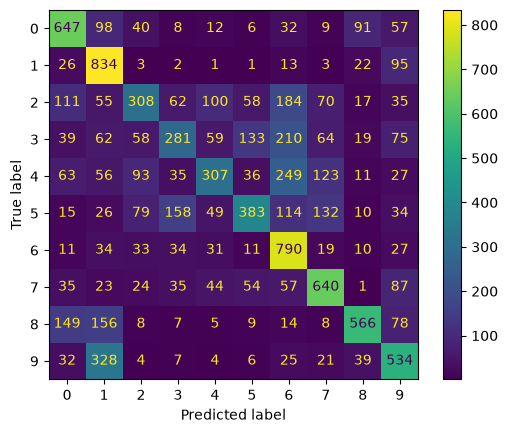

In [5]:
show_confusion_matrix(test_data, predicted_classes)